In [39]:
# Project Description
# Using the AAPL (Apple Inc.) stock dataset, conduct the following analyses:



# Initial Data Exploration
# Load the dataset using Pandas. Check for null values and understand data types.
# Examine the time series properties of the data (e.g., frequency, trends).


# Data Visualization
# Utilize Matplotlib to plot closing prices and traded volume over time.
# Create a candlestick chart to depict high and low prices.


# Statistical Analysis
# Compute summary statistics (mean, median, standard deviation) for key columns.
# Analyze closing prices with a moving average.


# Hypothesis Testing
# Execute a t-test to compare average closing prices across different years.
# Examine daily returns’ distribution and test for normality using SciPy.


# Advanced Statistical Techniques (Bonus)
# Statistical Functions in NumPy: Employ NumPy’s statistical functions for in-depth stock data analysis.
# E.g., Use convolve for moving averages, or np.corrcoef to explore correlations between financial metrics.
# Analyze correlations between moving averages of closing prices and trading volume across time periods.


# Resources
# Dataset: download it here Apple Stock Prices From 1981 to 2023
# It may include data such as date, opening price, closing price, high and low prices, and trading volume.

# This information can be used to study trends and patterns in the stock market and make informed investment decisions.

# Date: Represents the date of the stock price.
# Open: Represents the opening stock price on that date.
# High: Represents the highest stock price on that date.
# Low: Represents the lowest stock price on that date.
# Close: Represents the closing stock price on that date.
# Adj close: Represents the adjusted closing stock price on that date (taking into account corporate actions such as splits).
# Volume: Represents the number of shares traded on that date.


# Project Submission
# Submit a Jupyter Notebook with :

# All analysis code and visualizations.
# Detailed explanations of findings at each step.
# A comprehensive summary of insights, focusing on advanced statistical analysis.
# A ‘Reflection’ section detailing challenges and solutions.
# Suggested structure:



# 1. Data Loading and Exploration
# 2. Data Visualization
# 3. Statistical Analysis
# 4. Hypothesis Testing
# 5. Advanced Statistical Techniques (Bonus)
#     - Signal Processing using SciPy
#     - Statistical Functions in NumPy
# 6. Summary and Insights
# 7. Reflection


# Guidance
# Experiment with different filters and parameters in signal processing techniques.
# Thoroughly understand each statistical function and its insights on the stock data.


In [4]:
# 1. Data Loading and Exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats


In [5]:
df = pd.read_csv("Apple Stock Prices (1981 to 2023).csv")
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1,05/01/1981,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
2,06/01/1981,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
3,07/01/1981,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
4,08/01/1981,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 non-null  int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 580.2+ KB


In [10]:
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
df = df.sort_values("Date")


In [11]:
df["Date"].dtype


dtype('<M8[ns]')

In [12]:
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
62,1981-01-04,0.108817,0.108817,0.108259,0.108259,0.084242,34070400
83,1981-01-05,0.126674,0.127790,0.126674,0.126674,0.098571,16553600
103,1981-01-06,0.147879,0.148438,0.147879,0.147879,0.115072,51251200
125,1981-01-07,0.115513,0.115513,0.114955,0.114955,0.089452,170464000
168,1981-01-09,0.095424,0.095982,0.095424,0.095424,0.074254,37027200


In [13]:
df.tail()


,Date,Open,High,Low,Close,Adj Close,Volume
10593,2023-06-01,126.010002,130.289993,124.889999,129.619995,129.619995,87686600
10594,2023-09-01,130.470001,133.410004,129.889999,130.149994,130.149994,70790800
10595,2023-10-01,130.259995,131.259995,128.119995,130.729996,130.729996,63896200
10596,2023-11-01,131.250000,133.509995,130.460007,133.490005,133.490005,69458900
10597,2023-12-01,133.880005,134.259995,131.440002,133.410004,133.410004,71379600


In [15]:
df["Year"] = df["Date"].dt.year


In [16]:
df[["Date", "Year"]].head()


,Date,Year
62,1981-01-04,1981
83,1981-01-05,1981
103,1981-01-06,1981
125,1981-01-07,1981
168,1981-01-09,1981


In [17]:
# The Date column was initially stored as an object, meaning Pandas did not interpret it as a real date. 
# I converted it to datetime format using the exact day/month/year format. 
# Then, I sorted the dataset chronologically and created a Year column, which will be useful later for comparing stock prices across years.


In [18]:
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume,Year
62,1981-01-04,0.108817,0.108817,0.108259,0.108259,0.084242,34070400,1981
83,1981-01-05,0.126674,0.127790,0.126674,0.126674,0.098571,16553600,1981
103,1981-01-06,0.147879,0.148438,0.147879,0.147879,0.115072,51251200,1981
125,1981-01-07,0.115513,0.115513,0.114955,0.114955,0.089452,170464000,1981
168,1981-01-09,0.095424,0.095982,0.095424,0.095424,0.074254,37027200,1981


In [21]:
df.describe()


,Open,High,Low,Close,Adj Close,Volume,Year
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04,10608.000000
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08,2001.513763
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08,12.147246
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00,1981.000000
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08,1991.000000
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08,2002.000000
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08,2012.000000
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09,2023.000000


In [20]:
df.isnull().sum()


Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
Year         0
dtype: int64

In [22]:
df["Date"].min(), df["Date"].max()


(Timestamp('1981-01-04 00:00:00'), Timestamp('2023-12-01 00:00:00'))

In [23]:
df["Year"].value_counts().sort_index()


1981    253
1982    253
1983    253
1984    253
1985    252
1986    253
1987    253
1988    253
1989    252
1990    253
1991    253
1992    254
1993    253
1994    252
1995    252
1996    254
1997    253
1998    252
1999    252
2000    252
2001    248
2002    252
2003    252
2004    252
2005    252
2006    251
2007    251
2008    253
2009    252
2010    252
2011    252
2012    250
2013    252
2014    252
2015    252
2016    252
2017    251
2018    251
2019    252
2020    253
2021    252
2022    251
2023     18
Name: Year, dtype: int64

In [24]:
#trends

df["Date"].diff().value_counts().head(10)


1 days     7572
2 days     1531
3 days     1271
4 days      219
5 days        4
31 days       3
30 days       3
6 days        1
14 days       1
33 days       1
Name: Date, dtype: int64

In [25]:
# To examine the time series frequency, I calculated the difference between consecutive dates. 
# Most observations are separated by 1 day, which shows that the dataset is mainly daily.
# However, there are also 2-day and 3-day gaps, 
# which are expected in stock market data because markets are closed on weekends and holidays. 
# A few longer gaps, such as 30 or 31 days, may indicate missing periods or irregularities in the historical dataset.


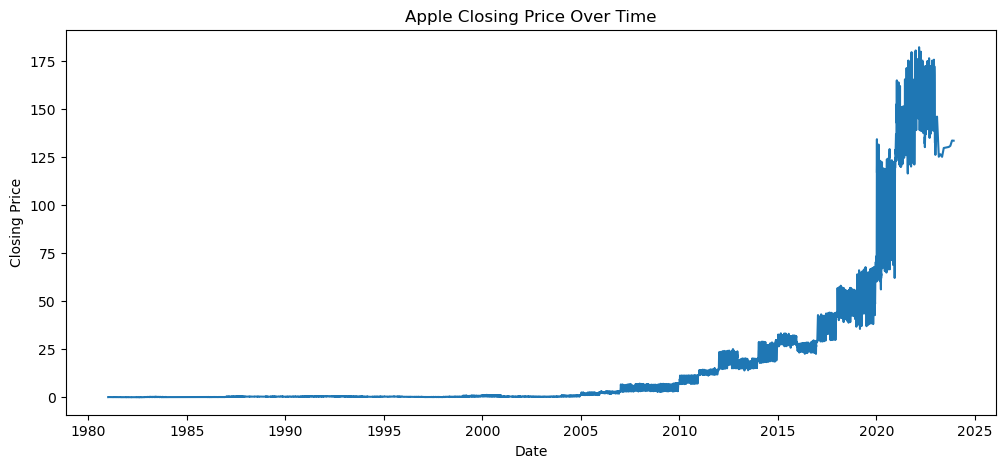

In [26]:
# 2. Data Visualization.

plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"])
plt.title("Apple Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()


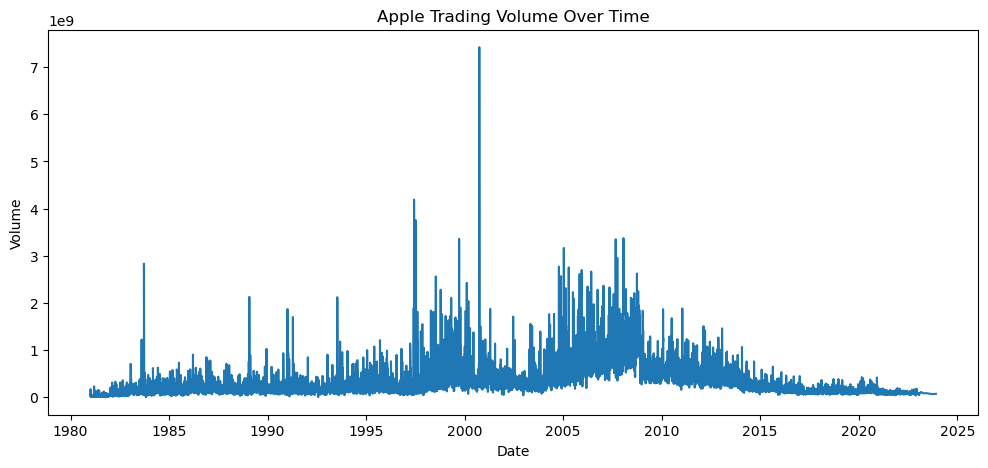

In [27]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Volume"])
plt.title("Apple Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()


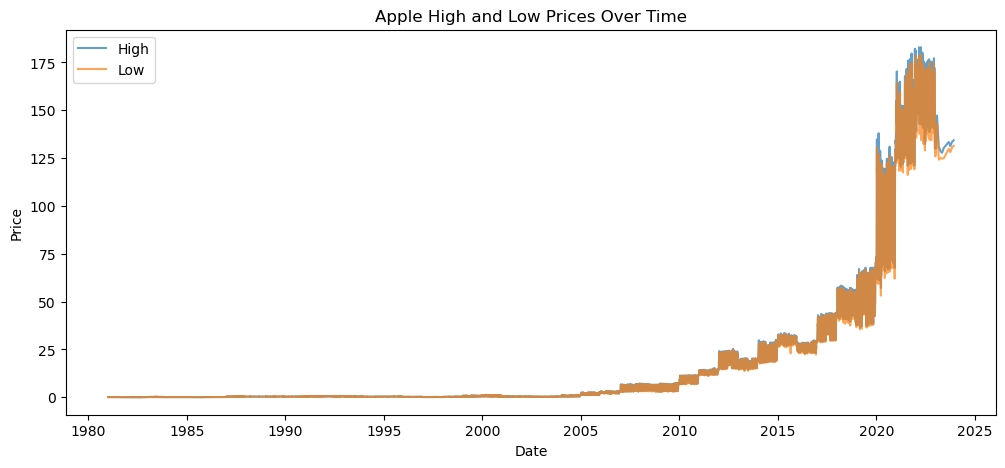

In [28]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["High"], label="High", alpha=0.7)
plt.plot(df["Date"], df["Low"], label="Low", alpha=0.7)
plt.title("Apple High and Low Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [30]:
import mplfinance as mpf


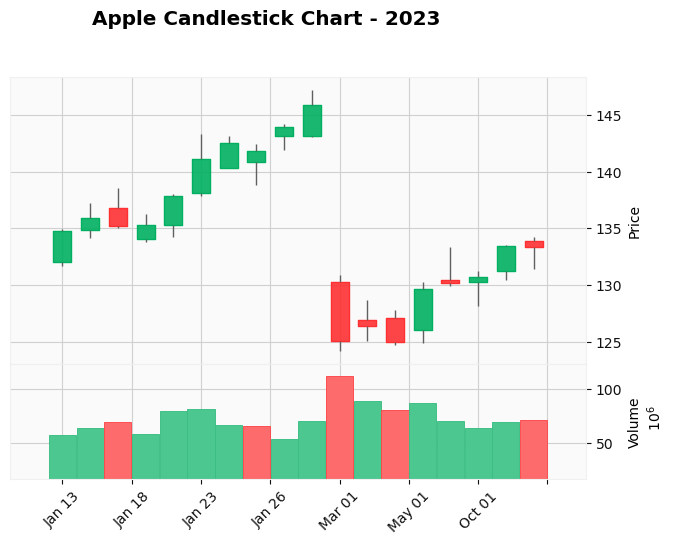

In [31]:
aapl_2023 = df[df["Year"] == 2023].set_index("Date")

mpf.plot(
    aapl_2023,
    type="candle",
    volume=True,
    style="yahoo",
    title="Apple Candlestick Chart - 2023",
    ylabel="Price",
    ylabel_lower="Volume"
)


In [32]:
# A candlestick chart was created using `mplfinance`, a library designed for financial visualizations.
# I used a subset of the data for 2023 because displaying the full dataset from 1981 to 2023 
# would make individual candles too compressed and difficult to interpret.


In [33]:
# The candlestick chart shows daily price movements using open, high, low, and close prices.
# Green candles represent days when the closing price was higher than the opening price, 
# while red candles represent days when the closing price was lower. 
# Larger candles indicate stronger daily price movements, 
# and longer wicks show a wider intraday range. 
# In this period, the chart shows an upward movement at first, 
# followed by a sharp decline around March 01 with high trading volume, 
# and then a gradual recovery.


In [34]:
# 3. Statistical Analysis.

df[["Open", "High", "Low", "Close", "Adj Close", "Volume"]].agg(["mean", "median", "std"])


,Open,High,Low,Close,Adj Close,Volume
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
median,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08


In [35]:
df["MA_30"] = df["Close"].rolling(window=30).mean()
df["MA_100"] = df["Close"].rolling(window=100).mean()


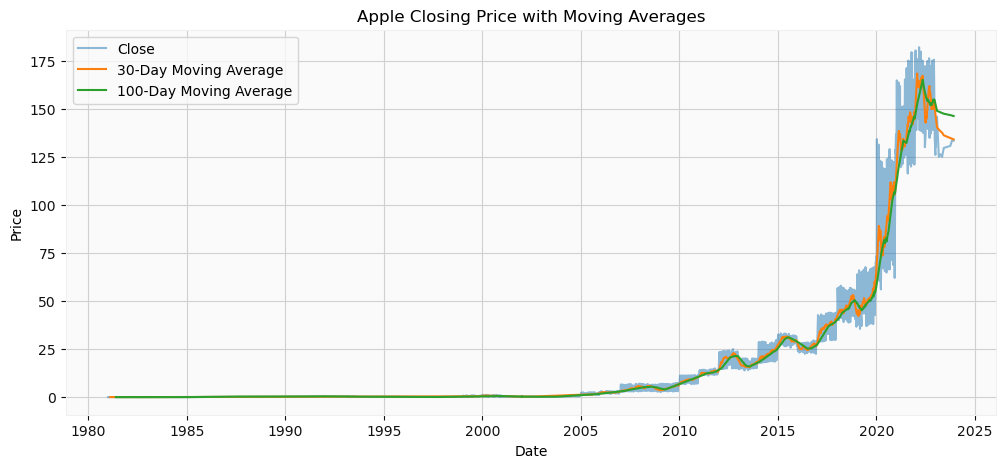

In [36]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"], label="Close", alpha=0.5)
plt.plot(df["Date"], df["MA_30"], label="30-Day Moving Average")
plt.plot(df["Date"], df["MA_100"], label="100-Day Moving Average")
plt.title("Apple Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()



In [37]:
# The moving averages smooth daily fluctuations and make the long-term trend easier to observe. 
# The 30-day moving average reacts more quickly to recent price changes,
# while the 100-day moving average is smoother and reflects a longer-term trend.
# The chart shows that Apple’s closing price remained relatively low for many years, 
# then increased strongly after the late 2000s, with a particularly sharp rise after 2019. 
# After reaching a peak around 2022, the closing price declined, and the moving averages also started to decrease.


In [40]:
# 4. Hypothesis Testing.
# Execute a t-test to compare average closing prices across different years.

# H0: the average closing prices are equal in 2021 and 2022.
# H1: the average closing prices are different in 2021 and 2022.


close_2021 = df[df["Year"] == 2021]["Close"]
close_2022 = df[df["Year"] == 2022]["Close"]

t_stat, p_value = stats.ttest_ind(close_2021, close_2022, equal_var=False)

t_stat, p_value

(-11.186566370059161, 4.7097114017671295e-26)

In [41]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: the average closing prices are significantly different.")
else:
    print("Fail to reject H0: no significant difference in average closing prices.")


Reject H0: the average closing prices are significantly different.


In [42]:
# The Welch’s t-test returned a p-value much smaller than 0.05. 
# Therefore, I reject the null hypothesis and conclude that 
# the average closing prices in 2021 and 2022 are statistically significantly different.
# The negative t-statistic indicates that the average closing price in 2021 was lower 
# than the average closing price in 2022.


In [43]:
# This test identifies a statistical difference in average closing prices, b
# ut it does not explain the economic or market reasons behind the difference.


In [44]:
# Examine daily returns’ distribution and test for normality using SciPy.
df["Daily_Return"] = df["Close"].pct_change()


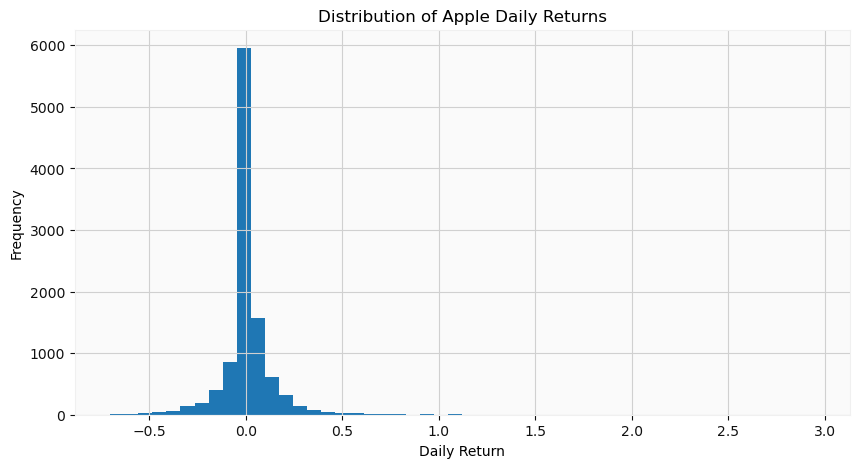

In [45]:
plt.figure(figsize=(10, 5))
plt.hist(df["Daily_Return"].dropna(), bins=50)
plt.title("Distribution of Apple Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


In [46]:
stat, p_value_normality = stats.normaltest(df["Daily_Return"].dropna())

stat, p_value_normality


(9363.82260573798, 0.0)

In [47]:
# H0: daily returns follow a normal distribution
# H1: daily returns do not follow a normal distribution
alpha = 0.05

if p_value_normality < alpha:
    print("Reject H0: daily returns do not follow a normal distribution.")
else:
    print("Fail to reject H0: daily returns may follow a normal distribution.")

Reject H0: daily returns do not follow a normal distribution.


In [48]:
# The normality test returned a p-value of 0.0, which means the p-value is extremely small.
# Since it is below the 0.05 significance level, I reject the null hypothesis. 
# This suggests that Apple’s daily returns do not follow a normal distribution. 
# This is common in financial data, where returns often show extreme values and heavier tails 
# than a normal distribution.


In [50]:
df["Daily_Return"].describe()

count    10607.000000
mean         0.010724
std          0.150831
min         -0.703805
25%         -0.023254
50%          0.001485
75%          0.031816
max          2.947605
Name: Daily_Return, dtype: float64

In [51]:
# In this section, I used hypothesis testing to compare closing prices between two years 
# and to test whether daily returns follow a normal distribution. 
# The t-test showed a statistically significant difference between the average closing prices in 2021 and 2022. 
# The normality test showed that daily returns do not follow a normal distribution, 
# which is common for financial data because stock returns often include extreme positive and negative movements.


In [52]:
# These tests provide statistical evidence, but they do not explain the economic causes behind the differences 
# or the non-normality.


In [53]:
# 5. Advanced Statistical Techniques (Bonus)

window = 30
weights = np.ones(window) / window

ma_30_np = np.convolve(df["Close"], weights, mode="valid")


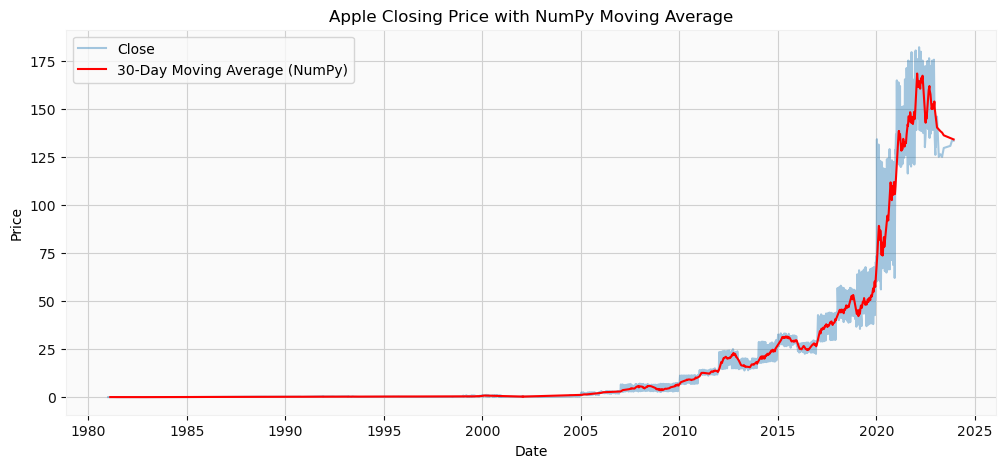

In [54]:
plt.figure(figsize=(12, 5))
plt.plot(df["Date"], df["Close"], label="Close", alpha=0.4)
plt.plot(df["Date"].iloc[window-1:], ma_30_np, label="30-Day Moving Average (NumPy)", color="red")
plt.title("Apple Closing Price with NumPy Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()


In [55]:
corr_close_volume = np.corrcoef(df["Close"], df["Volume"])[0, 1]
corr_close_volume


-0.21493342533575605

In [56]:
# The correlation between closing price and trading volume is approximately -0.21.
# This indicates a weak negative linear relationship. 
# In other words, higher closing prices are slightly associated with lower trading volume, 
# but the relationship is not strong. This correlation does not imply causation.


In [57]:
df_corr = df.dropna(subset=["MA_30", "Volume"])

corr_ma30_volume = np.corrcoef(df_corr["MA_30"], df_corr["Volume"])[0, 1]
corr_ma30_volume


-0.21525011538732042

In [58]:
# The correlation between the 30-day moving average and trading volume is approximately -0.22,
# which is very close to the correlation between the daily closing price and volume. 
# This suggests that smoothing the closing price with a moving average does not reveal a stronger linear relationship
# with trading volume. The relationship remains weakly negative.


In [59]:
# Overall, the NumPy analysis shows that moving averages can be computed using convolution,
# and correlation coefficients can help measure linear relationships between financial variables. 
# In this dataset, both the closing price and the 30-day moving average show only a weak negative correlation 
# with trading volume.


In [60]:
# 6. Summary and Insights

# This project analyzed Apple stock price data using exploratory analysis, visualization, statistical analysis, 
# hypothesis testing, and advanced NumPy functions.

# The dataset is a financial time series with observations recorded mainly on trading days. 
# Most date gaps are one day, but some longer gaps appear because stock markets are closed on weekends and holidays. 
# The closing price plot and moving averages show a strong long-term upward trend, especially after the late 2000s 
# and more sharply after 2019.

# The visualizations showed that Apple’s closing price increased substantially over time, 
# although there were periods of volatility and decline. The candlestick chart helped show daily price movements 
# using open, high, low, and close prices, while the volume plot showed periods of higher market activity.

# The statistical analysis showed that moving averages are useful for smoothing short-term fluctuations 
# and observing longer-term trends. 
# The 30-day moving average reacts more quickly to recent price changes, 
# while the 100-day moving average provides a smoother long-term view.

# The hypothesis tests provided additional insights. 
# The t-test comparing 2021 and 2022 showed a statistically significant difference in average closing prices. 
# The normality test showed that daily returns do not follow a normal distribution, 
# which is common in financial data because stock returns often include extreme positive and negative movements.

# Finally, NumPy functions were used for additional analysis.
# `np.convolve` was used to compute a moving average, and `np.corrcoef` was used to measure correlations
# between closing prices, moving averages, and trading volume. 
# The correlations with volume were weakly negative, suggesting that trading volume does not have a strong linear 
# relationship with the closing price or the 30-day moving average in this dataset.



In [61]:
# 7. Reflection

# One challenge was preparing the Date column correctly. 
# Although the dates appeared readable, they were initially stored as objects, 
# so I converted them to datetime format to make time series analysis possible. 

# Another challenge was understanding the candlestick chart, 
# because it displays several pieces of information at once: open, high, low, close, and volume. 
# Breaking down the chart into individual candles helped me understand how to interpret daily price movements.

# I also learned that statistical tests require careful interpretation. 
# A significant t-test result shows that average prices differ between years, 
# but it does not explain the economic reasons behind the difference. 
# Similarly, the normality test showed that daily returns are not normally distributed, 
# which is important because financial data often contains extreme values.

# This project helped me understand how data visualization, moving averages, 
# hypothesis testing, and correlation analysis can work together to analyze financial time series data.
